# A First Scikit-learn Model

This notebook walks through the scikit-learn estimator API -- `fit`, `predict`, `predict_proba` and `score` -- and the fitted attributes ending in `_`, using the Wine dataset.

## Import Required Libraries

Import the dataset, two classifiers and the plotting tools.

In [1]:
# Import the required libraries.
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

# Define the course colour palette.
colors = ["#179E86", "#2580B7", "#9EBE5B", "#C03B26", "#44546A"]

## Load and Split the Wine Dataset

Load the 13-feature Wine dataset and hold out a test set for honest scoring.

In [2]:
# Load the Wine dataset and split into train and test sets.
wine = load_wine()
X, y = wine.data, wine.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Classes: {list(wine.target_names)}")

Train: (124, 13), Test: (54, 13)
Classes: [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]


## fit: Learning From Data

Scaling the features and calling `fit` trains a k-nearest neighbours classifier.

In [3]:
# Scale the features and fit a k-NN classifier.
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_s, y_train)
print(f"Fitted estimator: {knn}")

Fitted estimator: KNeighborsClassifier()


## predict and score

`predict` returns hard labels while `score` reports the mean accuracy on a dataset.

In [4]:
# Predict labels and evaluate accuracy on the test set.
y_pred = knn.predict(X_test_s)
print(f"First predictions: {y_pred[:8]}")
print(f"k-NN test accuracy: {knn.score(X_test_s, y_test):.3f}")

First predictions: [0 1 0 0 0 0 2 1]
k-NN test accuracy: 0.944


## predict_proba: Class Probabilities

`predict_proba` returns the estimated probability of each class for every instance.

In [5]:
# Inspect the predicted class probabilities.
proba = knn.predict_proba(X_test_s)
print(f"Probability matrix shape: {proba.shape}")
print("First three rows (rounded):")
print(np.round(proba[:3], 2))

Probability matrix shape: (54, 3)
First three rows (rounded):
[[1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]]


## Fitted Attributes End With an Underscore

Fitting a logistic regression exposes learned attributes such as `coef_`, `intercept_` and `classes_`.

In [6]:
# Fit logistic regression and inspect its learned attributes.
logreg = LogisticRegression(max_iter=5000)
logreg.fit(X_train_s, y_train)
print(f"classes_: {logreg.classes_}")
print(f"coef_ shape: {logreg.coef_.shape}")
print(f"intercept_: {logreg.intercept_.round(2)}")
print(f"LogReg test accuracy: "
      f"{logreg.score(X_test_s, y_test):.3f}")

classes_: [0 1 2]
coef_ shape: (3, 13)
intercept_: [ 0.34  0.83 -1.17]
LogReg test accuracy: 0.981


## Decision Boundary on Two Features

Using only two features we can draw the region each class occupies in the input plane.

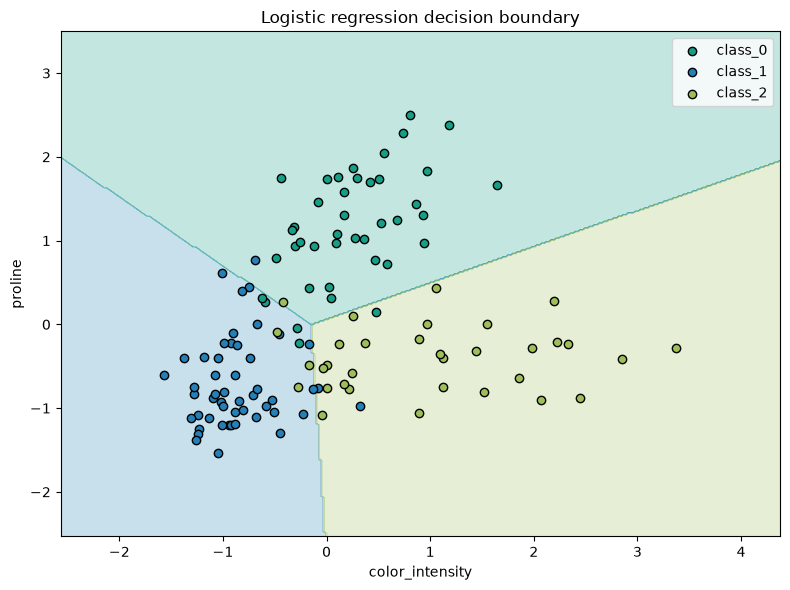

In [7]:
# Train on two features and plot the decision boundary.
feat = [9, 12]
X2 = StandardScaler().fit_transform(X_train[:, feat])
clf2 = LogisticRegression(max_iter=5000).fit(X2, y_train)

x_min, x_max = X2[:, 0].min() - 1, X2[:, 0].max() + 1
y_min, y_max = X2[:, 1].min() - 1, X2[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
zz = clf2.predict(grid).reshape(xx.shape)

from matplotlib.colors import ListedColormap
cmap = ListedColormap(colors[:3])
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, zz, alpha=0.25, cmap=cmap)
for k in np.unique(y_train):
    mask = y_train == k
    plt.scatter(X2[mask, 0], X2[mask, 1], color=colors[k],
                edgecolor="k", label=wine.target_names[k])
plt.title("Logistic regression decision boundary")
plt.xlabel(wine.feature_names[feat[0]])
plt.ylabel(wine.feature_names[feat[1]])
plt.legend()
plt.tight_layout()
plt.show()

## Summary

- **fit**: learns parameters from the training data.
- **predict**: returns hard class labels.
- **predict_proba**: returns per-class probabilities.
- **score**: reports mean accuracy on a dataset.
- **Fitted attributes**: learned values such as `coef_` and `classes_` end with an underscore.